# Trabajo Final de Machine Learning - Ejercicio 2
## Clasificacion: contratacion de deposito a plazo

**Grupo:** completar
**Integrantes:** completar

Se predice si un cliente suscribira (`yes`) o no (`no`) un deposito bancario a largo plazo.

## 1. Metadata y planteamiento

El dataset Bank Marketing registra campanas telefonicas de una institucion bancaria. La variable objetivo es `y`. Se utiliza `bank-full.csv`, disponible dentro de `bank.zip`, con separador punto y coma.

Como existe desbalance de clases, se reportan precision, recall, F1, ROC-AUC y matriz de confusion, ademas de accuracy.

In [1]:
from pathlib import Path
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42

In [2]:
BANK_DIR = Path('/Users/alexis/Downloads/bank+marketing')
ZIP_PATH = BANK_DIR / 'bank.zip'
if ZIP_PATH.exists():
    with zipfile.ZipFile(ZIP_PATH) as archive:
        member = next(name for name in archive.namelist() if name.endswith('bank-full.csv'))
        with archive.open(member) as file: df = pd.read_csv(file, sep=';')
else:
    candidates = list(Path('.').glob('**/bank-full.csv'))
    if not candidates: raise FileNotFoundError('No se encontro bank-full.csv ni bank.zip')
    df = pd.read_csv(candidates[0], sep=';')
print(f'Dimensiones: {df.shape}')
display(df.head())
display(df['y'].value_counts(normalize=True).rename('proporcion').to_frame())

Dimensiones: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


,proporcion
y,
no,0.883015
yes,0.116985


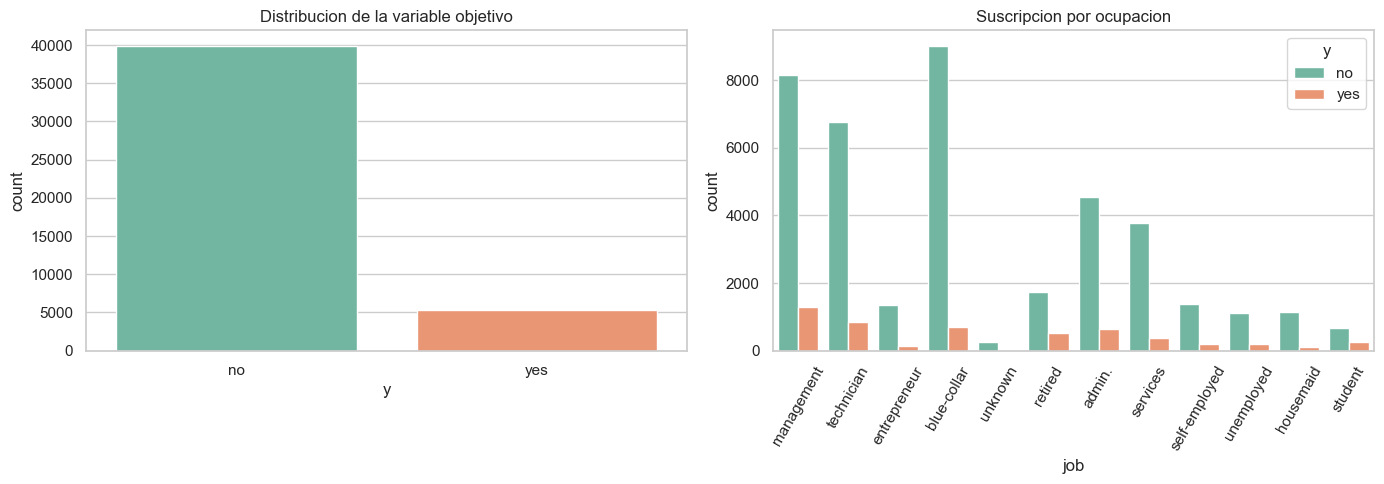

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='y', ax=axes[0], hue='y', legend=False, palette='Set2')
axes[0].set_title('Distribucion de la variable objetivo')
sns.countplot(data=df, x='job', hue='y', ax=axes[1], palette='Set2')
axes[1].set_title('Suscripcion por ocupacion')
axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()
display(df.describe(include='all').T.head(25))

## 2. Preparacion y modelos

Se eliminan `duration` y `contact` del modelado: `duration` solo se conoce despues de realizar la llamada y produciria fuga de informacion para una prediccion operativa. Las variables categoricas se imputan y codifican con one-hot; las numericas se imputan y estandarizan dentro del pipeline.

In [4]:
X = df.drop(columns='y').copy()
y = df['y'].map({'no': 0, 'yes': 1})
X = X.drop(columns=['duration', 'contact'], errors='ignore')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', numeric_pipe, numeric_features), ('cat', categorical_pipe, categorical_features)])
models = {
    'Regresion logistica': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=250, min_samples_leaf=2, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
}

In [5]:
results = []
fitted_models = {}
for name, estimator in models.items():
    model = Pipeline([('prep', preprocessor), ('model', estimator)])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    fitted_models[name] = model
    results.append({'Modelo': name, 'Accuracy': accuracy_score(y_test, pred), 'Precision': precision_score(y_test, pred), 'Recall': recall_score(y_test, pred), 'F1': f1_score(y_test, pred), 'ROC-AUC': roc_auc_score(y_test, proba)})
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
display(results_df.style.format({c:'{:.3f}' for c in results_df.columns if c != 'Modelo'}))

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,0.885,0.513,0.383,0.439,0.787
0,Regresion logistica,0.762,0.269,0.599,0.371,0.752
2,Gradient Boosting,0.894,0.657,0.201,0.308,0.784


,Modelo,ROC-AUC CV promedio,Desvio CV
1,Random Forest,0.778,0.011
2,Gradient Boosting,0.777,0.010
0,Regresion logistica,0.748,0.011


Modelo seleccionado por F1: Random Forest
              precision    recall  f1-score   support

          No       0.92      0.95      0.94      7985
          Si       0.51      0.38      0.44      1058

    accuracy                           0.89      9043
   macro avg       0.72      0.67      0.69      9043
weighted avg       0.87      0.89      0.88      9043



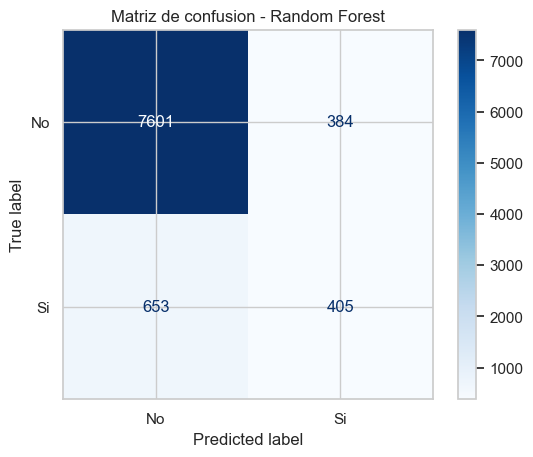

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in fitted_models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_rows.append({'Modelo': name, 'ROC-AUC CV promedio': scores.mean(), 'Desvio CV': scores.std()})
display(pd.DataFrame(cv_rows).sort_values('ROC-AUC CV promedio', ascending=False).style.format({'ROC-AUC CV promedio':'{:.3f}', 'Desvio CV':'{:.3f}'}))

best_name = results_df.iloc[0]['Modelo']
best_pred = fitted_models[best_name].predict(X_test)
print(f'Modelo seleccionado por F1: {best_name}')
print(classification_report(y_test, best_pred, target_names=['No', 'Si']))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=['No', 'Si'], cmap='Blues')
plt.title(f'Matriz de confusion - {best_name}')
plt.show()

## 3. Interpretacion y conclusiones

- El modelo se selecciona priorizando F1 y ROC-AUC, porque identificar potenciales suscriptores es mas informativo que maximizar accuracy en una clase minoritaria.
- Recall indica cuantos clientes que efectivamente contratarian fueron detectados; precision indica que proporción de los contactados por el modelo resulto positiva.
- La matriz de confusion permite cuantificar falsos positivos y falsos negativos.
- La eliminacion de `duration` evita usar informacion posterior al contacto; esto hace que la evaluacion sea mas realista para decidir a quien contactar.

**Limitaciones:** los datos provienen de una campaña y un periodo concretos; puede existir cambio de comportamiento, sesgo de selección y necesidad de calibrar el umbral según el coste comercial de cada error.